<a href="https://colab.research.google.com/github/KholilTCM/PMML/blob/main/UTS_Credit_Default_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import

In [31]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)
from IPython.display import display

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42
print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.6.1



# Experiment 0 — Data Understanding & Preparation

## 0.1 Membaca dataset
Dataset dibaca apa adanya. Jika dijalankan di Google Colab dan file belum ada, akan muncul dialog upload untuk file `UCI_Credit_Card.csv`

In [32]:
DATA_PATH = "UCI_Credit_Card.csv"

if not os.path.exists(DATA_PATH):
    try:
        from google.colab import files
        print("Upload file UCI_Credit_Card.csv")
        files.upload()
    except ImportError:
        raise FileNotFoundError("Letakkan UCI_Credit_Card.csv di folder yang sama dengan notebook.")

df = pd.read_csv(DATA_PATH)
display(df.head())

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## 0.2 Dimensi, struktur, dan tipe data

In [33]:
print("Dimensi dataset (baris, kolom):", df.shape)
print()
df.info()

Dimensi dataset (baris, kolom): (30000, 25)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null 

In [34]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


## 0.3 Variabel target
Target adalah `default.payment.next.month`. Kolom `ID` hanyalah nomor identitas sehingga tidak digunakan sebagai predictor.

,jumlah,persen (%)
default.payment.next.month,,
0,23364,77.88
1,6636,22.12


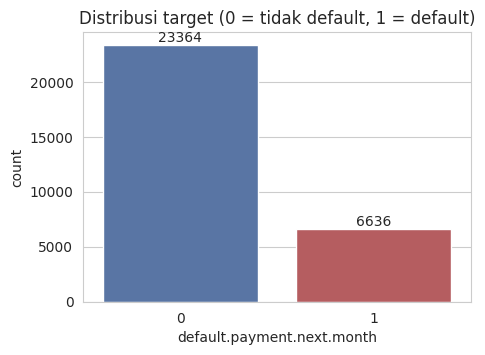

In [35]:
TARGET = "default.payment.next.month"

counts = df[TARGET].value_counts().sort_index()
percent = df[TARGET].value_counts(normalize=True).sort_index() * 100
display(pd.DataFrame({"jumlah": counts, "persen (%)": percent.round(2)}))

fig, ax = plt.subplots(figsize=(5, 3.5))
sns.countplot(x=TARGET, data=df, ax=ax, palette=["#4C72B0", "#C44E52"])
ax.set_title("Distribusi target (0 = tidak default, 1 = default)")
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")
plt.show()

**Temuan:** kelas tidak seimbang (*imbalanced*) — mayoritas nasabah tidak default (~78%) dan hanya ~22% default. Konsekuensinya, *accuracy* kurang informatif (model yang selalu menebak "tidak default" sudah mendapat ~78%), sehingga F1-score kelas default dipakai sebagai metrik utama.

## 0.4 Missing value dan duplicate

In [36]:
missing = df.isnull().sum()
print("Total missing value:", int(missing.sum()))
display(missing[missing > 0] if missing.sum() > 0 else pd.Series({"Tidak ada missing value": 0}))

print("\nDuplikat ID                    :", df["ID"].duplicated().sum())
print("Duplikat baris penuh           :", df.duplicated().sum())
print("Duplikat baris (tanpa kolom ID):", df.drop(columns="ID").duplicated().sum())

Total missing value: 0


,0
Tidak ada missing value,0



Duplikat ID                    : 0
Duplikat baris penuh           : 0
Duplikat baris (tanpa kolom ID): 35


**Temuan:** tidak ada missing value. ID unik. Ada sejumlah kecil baris yang identik pada seluruh fitur selain ID. Baris tersebut **tidak dihapus**, karena dua nasabah berbeda memang dapat memiliki profil dan riwayat pembayaran yang sama (terutama nasabah dengan tagihan dan pembayaran nol), dan jumlahnya sangat kecil (< 0,2%) sehingga tidak berpengaruh material.

## 0.5 Pemeriksaan nilai tidak sesuai / tidak wajar

Kolom kategorikal dibandingkan dengan deskripsi dataset: SEX (1 = laki-laki, 2 = perempuan), EDUCATION (1 = pascasarjana, 2 = universitas, 3 = SMA, 4 = lainnya), dan MARRIAGE (1 = menikah, 2 = lajang, 3 = lainnya).

In [37]:
for col in ["SEX", "EDUCATION", "MARRIAGE"]:
    print(f"--- {col} ---")
    print(df[col].value_counts().sort_index().to_string())
    print()

--- SEX ---
SEX
1    11888
2    18112

--- EDUCATION ---
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51

--- MARRIAGE ---
MARRIAGE
0       54
1    13659
2    15964
3      323



In [38]:
# Kolom riwayat pembayaran PAY_*: -2 = tidak ada tagihan, -1 = lunas, 0 = revolving,
# 1..9 = keterlambatan (bulan).
pay_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
bill_cols = [f"BILL_AMT{i}" for i in range(1, 7)]
payamt_cols = [f"PAY_AMT{i}" for i in range(1, 7)]

display(pd.DataFrame({c: df[c].value_counts().sort_index() for c in pay_cols}).fillna(0).astype(int))

print("Rentang AGE        :", df["AGE"].min(), "-", df["AGE"].max())
print("Rentang LIMIT_BAL  :", df["LIMIT_BAL"].min(), "-", df["LIMIT_BAL"].max())
print("Jumlah BILL_AMT < 0:", int((df[bill_cols] < 0).sum().sum()), "(tagihan negatif = kelebihan bayar, valid)")
print("Jumlah PAY_AMT  < 0:", int((df[payamt_cols] < 0).sum().sum()))

,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
-2,2759,3782,4085,4348,4546,4895
-1,5686,6050,5938,5687,5539,5740
0,14737,15730,15764,16455,16947,16286
1,3688,28,4,2,0,0
2,2667,3927,3819,3159,2626,2766
3,322,326,240,180,178,184
4,76,99,76,69,84,49
5,26,25,21,35,17,13
6,11,12,23,5,4,19
7,9,20,27,58,58,46


Rentang AGE        : 21 - 79
Rentang LIMIT_BAL  : 10000.0 - 1000000.0
Jumlah BILL_AMT < 0: 3932 (tagihan negatif = kelebihan bayar, valid)
Jumlah PAY_AMT  < 0: 0


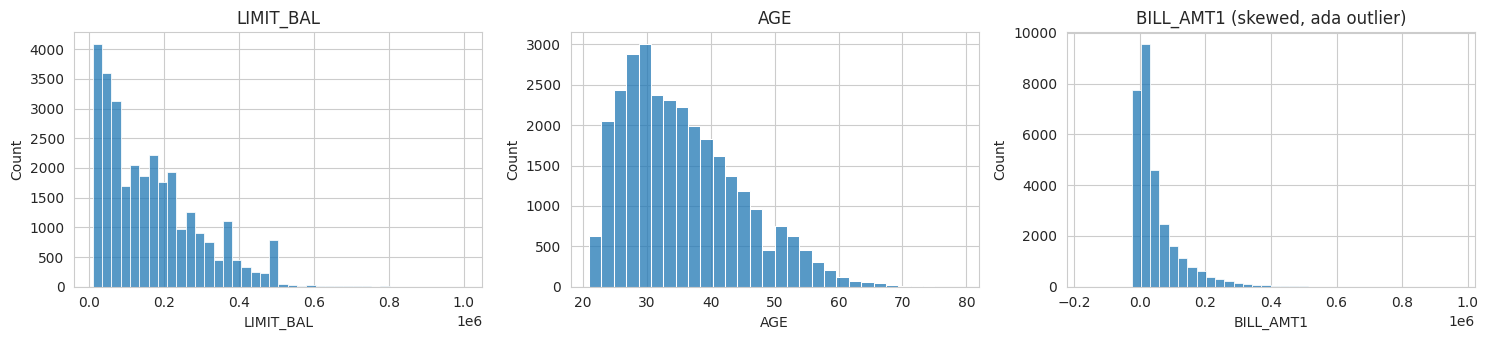

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
sns.histplot(df["LIMIT_BAL"], bins=40, ax=axes[0]); axes[0].set_title("LIMIT_BAL")
sns.histplot(df["AGE"], bins=30, ax=axes[1]); axes[1].set_title("AGE")
sns.histplot(df["BILL_AMT1"], bins=40, ax=axes[2]); axes[2].set_title("BILL_AMT1 (skewed, ada outlier)")
plt.tight_layout(); plt.show()

**Temuan nilai tidak sesuai:**
- `EDUCATION` memiliki kode 0, 5, 6 yang tidak ada dalam deskripsi (valid hanya 1–4) → digabungkan ke kategori `4` (lainnya).
- `MARRIAGE` memiliki kode 0 yang tidak terdokumentasi (valid 1–3) → digabungkan ke kategori `3` (lainnya).
- `PAY_*` memiliki nilai -2, -1, 0 yang tidak terdokumentasi pada deskripsi resmi, tetapi merupakan kode yang konsisten (tidak ada tagihan / lunas / revolving) → dipertahankan sebagai fitur ordinal.
- `AGE` (21–79) dan `LIMIT_BAL` wajar. `BILL_AMT` negatif adalah kelebihan pembayaran → dipertahankan. Ada outlier pada nilai uang yang sangat skewed, namun tetap data valid sehingga tidak dibuang (cukup di-scale).

## 0.6 Hubungan fitur dengan target (eksplorasi singkat)

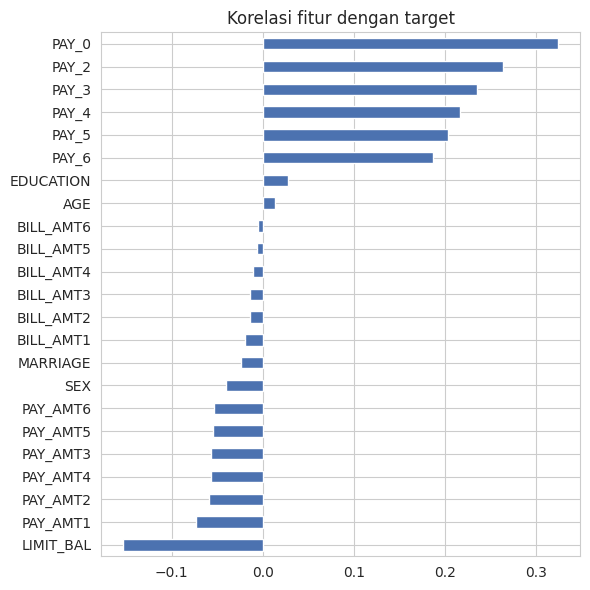

Fitur paling berkorelasi: ['PAY_0', 'PAY_2', 'PAY_3']


In [40]:
corr = df.drop(columns="ID").corr()[TARGET].drop(TARGET).sort_values()
fig, ax = plt.subplots(figsize=(6, 6))
corr.plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Korelasi fitur dengan target"); plt.tight_layout(); plt.show()
print("Fitur paling berkorelasi:", corr.abs().sort_values(ascending=False).head(3).index.tolist())

Fitur status pembayaran (`PAY_0`, `PAY_2`, ...) memiliki korelasi paling kuat dengan default — masuk akal karena keterlambatan bayar bulan lalu adalah sinyal risiko terkuat.

## 0.7 Menentukan predictor & target, serta train-test split
- Target `y` = `default.payment.next.month`
- Predictor `X` = seluruh kolom lain kecuali `ID`
- Train-test split dilakukan sebelum preprocessing apa pun yang mempelajari statistik data (scaling/encoding) agar tidak terjadi *data leakage*. Split 80/20 dengan `stratify=y` agar proporsi default sama di train dan test.

In [41]:
X = df.drop(columns=["ID", TARGET])
y = df[TARGET]
print("Jumlah predictor:", X.shape[1])
print("Predictor       :", X.columns.tolist())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("\nX_train:", X_train.shape, "| X_test:", X_test.shape)
print("Proporsi default (train): %.4f" % y_train.mean())
print("Proporsi default (test) : %.4f" % y_test.mean())

Jumlah predictor: 23
Predictor       : ['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

X_train: (24000, 23) | X_test: (6000, 23)
Proporsi default (train): 0.2212
Proporsi default (test) : 0.2212


## 0.8 Preprocessing yang diperlukan
Berdasarkan pemeriksaan data, preprocessing yang relevan:

| Masalah | Keputusan | Leakage? |
|---|---|---|
| Kode `EDUCATION` 0/5/6 dan `MARRIAGE` 0 tidak valid | Pemetaan ke kategori "lainnya" (aturan tetap) | Tidak — aturan deterministik, tidak belajar dari data |
| `SEX`, `EDUCATION`, `MARRIAGE` bersifat nominal | One-Hot Encoding | Dimasukkan ke *Pipeline* |
| Skala fitur sangat berbeda (`LIMIT_BAL` ratusan ribu vs `PAY_*` -2..8) | StandardScaler pada fitur numerik | Dimasukkan ke *Pipeline* (di-fit hanya pada fold training) |
| Tidak ada missing value | Imputasi tidak diperlukan | – |
| Kelas tidak seimbang (22% default) | Dievaluasi pada Experiment 2B (`class_weight`) | – |

Scaling dan encoding dimasukkan ke dalam `Pipeline`, sehingga pada setiap fold Cross Validation parameter scaler/encoder hanya dipelajari dari data training fold tersebut, sehingga tidak terjadi data leakage.

> Experiment 1 (baseline) sengaja memakai data mentah tanpa preprocessing apa pun, agar Experiment 2 dapat dibandingkan secara adil.

In [42]:
def clean_categories(data):
    """Merapikan kode kategori tidak valid (aturan tetap, tidak belajar dari data)."""
    data = data.copy()
    data["EDUCATION"] = data["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
    data["MARRIAGE"] = data["MARRIAGE"].replace({0: 3})
    return data

X_train_clean = clean_categories(X_train)
X_test_clean = clean_categories(X_test)

print("EDUCATION (train, setelah dibersihkan):", sorted(X_train_clean["EDUCATION"].unique()))
print("MARRIAGE  (train, setelah dibersihkan):", sorted(X_train_clean["MARRIAGE"].unique()))

cat_cols = ["SEX", "EDUCATION", "MARRIAGE"]
num_cols = [c for c in X.columns if c not in cat_cols]

def build_preprocessor():
    return ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
        ("num", StandardScaler(), num_cols),
    ])

def make_pipe(clf):
    """Pipeline = preprocessing + model (preprocessing di-fit ulang di setiap fold CV)."""
    return Pipeline([("prep", build_preprocessor()), ("classifier", clf)])

EDUCATION (train, setelah dibersihkan): [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
MARRIAGE  (train, setelah dibersihkan): [np.int64(1), np.int64(2), np.int64(3)]


## 0.9 Prosedur evaluasi (dipakai di semua eksperimen)
- CV F1-score: rata-rata F1 dari 5-fold Stratified Cross Validation pada training set
- Test metrics: model di-fit pada seluruh training set, lalu dievaluasi sekali pada test set
- F1, Precision, Recall dihitung untuk kelas positif (1 = default)
- Model dipilih berdasarkan CV F1 (bukan test), sehingga test set tetap menjadi data uji yang murni

In [43]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

all_results = {}   # penampung hasil semua eksperimen

def test_metrics(model, Xtr, Xte, ytr, yte):
    pred = model.predict(Xte)
    return {
        "Test Accuracy": accuracy_score(yte, pred),
        "Test Precision": precision_score(yte, pred, zero_division=0),
        "Test Recall": recall_score(yte, pred, zero_division=0),
        "Test F1": f1_score(yte, pred, zero_division=0),
        "Train F1": f1_score(ytr, model.predict(Xtr), zero_division=0),
    }

def evaluate_model(model, Xtr, Xte, ytr, yte, name, key=None):
    """5-fold CV (F1) pada training set + evaluasi pada test set."""
    cv_scores = cross_validate(model, Xtr, ytr, cv=cv, scoring="f1", n_jobs=-1)["test_score"]
    model.fit(Xtr, ytr)
    res = {"Model": name, "CV F1": cv_scores.mean(), "CV F1 Std": cv_scores.std()}
    res.update(test_metrics(model, Xtr, Xte, ytr, yte))
    if key is not None:
        all_results[key] = res
    return res

METRIC_COLS = ["CV F1", "CV F1 Std", "Test Accuracy", "Test Precision", "Test Recall", "Test F1", "Train F1"]

def show_results(rows):
    out = pd.DataFrame(rows).set_index("Model")[METRIC_COLS]
    display(out.round(4))
    return out

---
# Experiment 1 — Baseline Model
Logistic Regression pada data mentah (tanpa pembersihan kategori, tanpa scaling, tanpa encoding).

In [44]:
baseline = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
res1 = evaluate_model(baseline, X_train, X_test, y_train, y_test,
                      "Logistic Regression (raw)", key="1")
_ = show_results([res1])

,CV F1,CV F1 Std,Test Accuracy,Test Precision,Test Recall,Test F1,Train F1
Model,,,,,,,
Logistic Regression (raw),0.356,0.0454,0.7945,0.7117,0.1191,0.204,0.1942


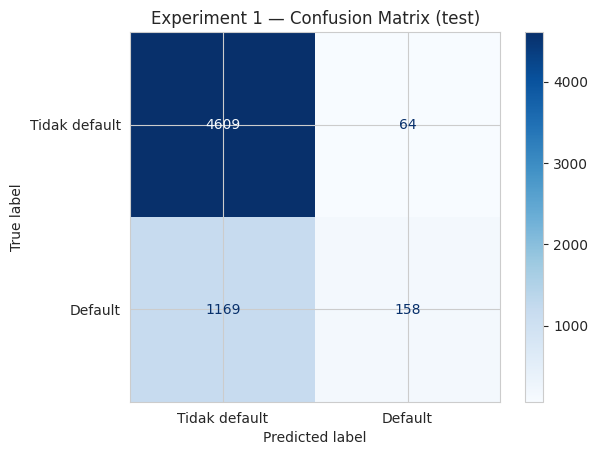

In [45]:
cm = confusion_matrix(y_test, baseline.predict(X_test))
ConfusionMatrixDisplay(cm, display_labels=["Tidak default", "Default"]).plot(cmap="Blues")
plt.title("Experiment 1 — Confusion Matrix (test)"); plt.show()

**Interpretasi singkat:** perhatikan perbedaan antara *Accuracy* (tinggi karena kelas mayoritas) dan *Recall/F1* kelas default (rendah). Baseline ini menjadi pembanding untuk eksperimen berikutnya.

---
# Experiment 2 — Preprocessing
Logistic Regression yang sama dibangun ulang dengan: pembersihan kategori tidak valid, One-Hot Encoding (`SEX`, `EDUCATION`, `MARRIAGE`), dan StandardScaler (fitur numerik), seluruhnya di dalam `Pipeline`.

In [46]:
lr_pre = make_pipe(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
res2 = evaluate_model(lr_pre, X_train_clean, X_test_clean, y_train, y_test,
                      "LR + cleaning + encoding + scaling", key="2")

comp = show_results([res1, res2])
delta = pd.Series({m: res2[m] - res1[m] for m in ["CV F1", "Test Accuracy", "Test Precision", "Test Recall", "Test F1"]})
print("\nPerubahan (Exp 2 - Exp 1):")
display(delta.round(4).to_frame("delta"))

,CV F1,CV F1 Std,Test Accuracy,Test Precision,Test Recall,Test F1,Train F1
Model,,,,,,,
Logistic Regression (raw),0.3560,0.0454,0.7945,0.7117,0.1191,0.204,0.1942
LR + cleaning + encoding + scaling,0.3653,0.0142,0.8088,0.6923,0.2442,0.361,0.3702



Perubahan (Exp 2 - Exp 1):


,delta
CV F1,0.0094
Test Accuracy,0.0143
Test Precision,-0.0194
Test Recall,0.1251
Test F1,0.1570


## Experiment 2B — Penanganan kelas tidak seimbang (`class_weight="balanced"`)
Pada Experiment 0 ditemukan kelas imbalanced. Karena F1 kelas default adalah metrik utama, diuji apakah `class_weight="balanced"` meningkatkan CV F1. Hasilnya menentukan apakah pengaturan ini dipakai pada Experiment 3–5 (keputusan berdasarkan CV, bukan test).

In [47]:
lr_bal = make_pipe(LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
res2b = evaluate_model(lr_bal, X_train_clean, X_test_clean, y_train, y_test,
                       "LR + preprocessing + class_weight=balanced", key="2B")
_ = show_results([res1, res2, res2b])

USE_BALANCED = res2b["CV F1"] > res2["CV F1"]
CLASS_WEIGHT = "balanced" if USE_BALANCED else None
print("\nKeputusan: class_weight =", CLASS_WEIGHT, "(dipakai pada Experiment 3, 4, dan 5)")

,CV F1,CV F1 Std,Test Accuracy,Test Precision,Test Recall,Test F1,Train F1
Model,,,,,,,
Logistic Regression (raw),0.3560,0.0454,0.7945,0.7117,0.1191,0.2040,0.1942
LR + cleaning + encoding + scaling,0.3653,0.0142,0.8088,0.6923,0.2442,0.3610,0.3702
LR + preprocessing + class_weight=balanced,0.4811,0.0117,0.6788,0.3681,0.6307,0.4649,0.4834



Keputusan: class_weight = balanced (dipakai pada Experiment 3, 4, dan 5)


---
# Experiment 3 — Model Comparison
Tiga model dengan prosedur evaluasi dan preprocessing yang sama (`Pipeline`, 5-fold CV, test set): Logistic Regression, Decision Tree, dan Random Forest (parameter default/awal, belum di-tuning). Model terbaik dipilih berdasarkan CV F1.

In [48]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight=CLASS_WEIGHT, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(class_weight=CLASS_WEIGHT, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight=CLASS_WEIGHT,
                                            random_state=RANDOM_STATE, n_jobs=-1),
}

exp3_rows = []
for name, clf in models.items():
    r = evaluate_model(make_pipe(clf), X_train_clean, X_test_clean, y_train, y_test, name, key=f"3-{name}")
    exp3_rows.append(r)

exp3_table = show_results(exp3_rows)

,CV F1,CV F1 Std,Test Accuracy,Test Precision,Test Recall,Test F1,Train F1
Model,,,,,,,
Logistic Regression,0.4811,0.0117,0.6788,0.3681,0.6307,0.4649,0.4834
Decision Tree,0.3881,0.0119,0.7273,0.3832,0.3821,0.3826,0.9986
Random Forest,0.4561,0.0080,0.8152,0.6531,0.3504,0.4561,0.9988


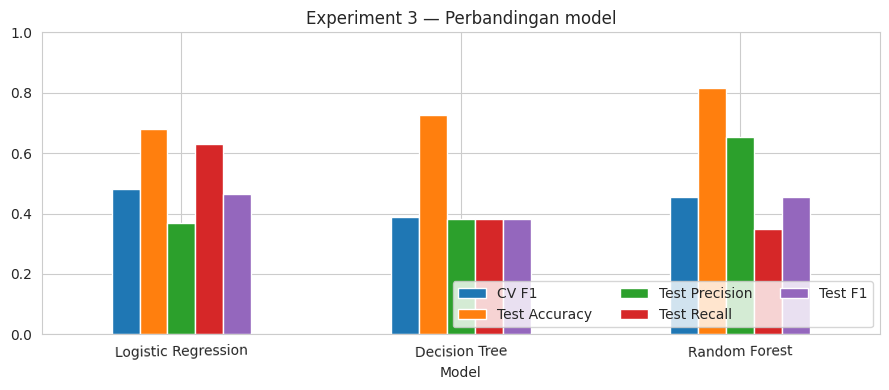

Model terbaik Experiment 3 (berdasarkan CV F1): Logistic Regression
Train F1 vs CV F1 (indikasi overfitting):


,Train F1,CV F1,Test F1
Model,,,
Logistic Regression,0.4834,0.4811,0.4649
Decision Tree,0.9986,0.3881,0.3826
Random Forest,0.9988,0.4561,0.4561


In [49]:
fig, ax = plt.subplots(figsize=(9, 4))
exp3_table[["CV F1", "Test Accuracy", "Test Precision", "Test Recall", "Test F1"]].plot(kind="bar", ax=ax, rot=1)
ax.set_title("Experiment 3 — Perbandingan model"); ax.set_ylim(0, 1); ax.legend(loc="lower right", ncol=3)
plt.tight_layout(); plt.show()

BEST_NAME = exp3_table["CV F1"].idxmax()
print("Model terbaik Experiment 3 (berdasarkan CV F1):", BEST_NAME)
print("Train F1 vs CV F1 (indikasi overfitting):")
display(exp3_table[["Train F1", "CV F1", "Test F1"]].round(4))

**Catatan:** selisih besar antara *Train F1* dan *CV/Test F1* menandakan overfitting (umumnya terjadi pada Decision Tree tanpa batas kedalaman). Model terbaik dipilih dari CV F1, lalu dilanjutkan ke Experiment 4.

---
# Experiment 4 — Hyperparameter Tuning
`GridSearchCV` dengan 5-fold CV dan `scoring="f1"` pada model terbaik dari Experiment 3. Grid hyperparameter disesuaikan dengan model yang terpilih.

In [50]:
param_grids = {
    "Logistic Regression": {
        "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100],
        "classifier__solver": ["lbfgs", "liblinear"],
    },
    "Decision Tree": {
        "classifier__max_depth": [3, 4, 5, 6, 8, 10, None],
        "classifier__min_samples_leaf": [1, 10, 50, 100],
        "classifier__criterion": ["gini", "entropy"],
    },
    "Random Forest": {
        "classifier__n_estimators": [100, 200],
        "classifier__max_depth": [6, 8, 12],
        "classifier__min_samples_leaf": [5, 20],
        "classifier__max_features": ["sqrt", 0.5],
    },
}

grid_params = param_grids[BEST_NAME]
print("Model yang di-tuning:", BEST_NAME)
print("Hyperparameter yang diuji:")
for k, v in grid_params.items():
    print(f"  {k.replace('classifier__', '')}: {v}")
n_comb = int(np.prod([len(v) for v in grid_params.values()]))
print(f"Total kombinasi: {n_comb}  x 5 fold = {n_comb * 5} fitting")

Model yang di-tuning: Logistic Regression
Hyperparameter yang diuji:
  C: [0.001, 0.01, 0.1, 1, 10, 100]
  solver: ['lbfgs', 'liblinear']
Total kombinasi: 12  x 5 fold = 60 fitting


In [51]:
base_estimator = make_pipe(models[BEST_NAME])
grid = GridSearchCV(base_estimator, grid_params, scoring="f1", cv=cv, n_jobs=-1, refit=True)
grid.fit(X_train_clean, y_train)

print("Kombinasi hyperparameter terbaik:")
best_params = {k.replace("classifier__", ""): v for k, v in grid.best_params_.items()}
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"\nBest CV F1-score: {grid.best_score_:.4f}")

cv_table = pd.DataFrame(grid.cv_results_).sort_values("rank_test_score")
cols = ["rank_test_score", "mean_test_score", "std_test_score"] + [c for c in cv_table.columns if c.startswith("param_")]
display(cv_table[cols].head(10).round(4))

Kombinasi hyperparameter terbaik:
  C: 0.01
  solver: liblinear

Best CV F1-score: 0.4821


,rank_test_score,mean_test_score,std_test_score,param_classifier__C,param_classifier__solver
3,1,0.4821,0.0115,0.01,liblinear
2,2,0.4819,0.0121,0.01,lbfgs
5,3,0.4816,0.0116,0.10,liblinear
11,4,0.4815,0.0115,100.00,liblinear
10,5,0.4815,0.0116,100.00,lbfgs
9,6,0.4814,0.0115,10.00,liblinear
7,7,0.4814,0.0116,1.00,liblinear
4,8,0.4813,0.0115,0.10,lbfgs
6,9,0.4811,0.0117,1.00,lbfgs
8,10,0.4809,0.0113,10.00,lbfgs


In [52]:
tuned = grid.best_estimator_
res4 = {"Model": f"{BEST_NAME} (tuned)", "CV F1": grid.best_score_,
        "CV F1 Std": cv_table.iloc[0]["std_test_score"]}
res4.update(test_metrics(tuned, X_train_clean, X_test_clean, y_train, y_test))
all_results["4"] = res4

before = all_results[f"3-{BEST_NAME}"].copy()
before["Model"] = f"{BEST_NAME} (sebelum tuning)"
print("Sebelum tuning vs sesudah tuning:")
tuning_table = show_results([before, res4])

dm = {m: res4[m] - before[m] for m in ["CV F1", "Test Accuracy", "Test Precision", "Test Recall", "Test F1"]}
display(pd.Series(dm).round(4).to_frame("delta (sesudah - sebelum)"))
print("Apakah tuning meningkatkan CV F1? ", "YA" if dm["CV F1"] > 0 else "TIDAK")
print("Apakah tuning meningkatkan Test F1?", "YA" if dm["Test F1"] > 0 else "TIDAK")

Sebelum tuning vs sesudah tuning:


,CV F1,CV F1 Std,Test Accuracy,Test Precision,Test Recall,Test F1,Train F1
Model,,,,,,,
Logistic Regression (sebelum tuning),0.4811,0.0117,0.6788,0.3681,0.6307,0.4649,0.4834
Logistic Regression (tuned),0.4821,0.0115,0.6815,0.3705,0.6292,0.4664,0.4844


,delta (sesudah - sebelum)
CV F1,0.0010
Test Accuracy,0.0027
Test Precision,0.0024
Test Recall,-0.0015
Test F1,0.0015


Apakah tuning meningkatkan CV F1?  YA
Apakah tuning meningkatkan Test F1? YA


---
# Experiment 5 — Advanced Model
**Gradient Boosting** (`HistGradientBoostingClassifier` dari scikit-learn): ensemble boosting berbasis decision tree yang dilatih secara berurutan. Dipilih karena data tabular berukuran menengah dan mendukung `class_weight`, sehingga perbandingannya adil dengan model sebelumnya. Prosedur evaluasi sama (Pipeline, 5-fold CV, test set). Parameter ditetapkan secara moderat (tanpa tuning terhadap test set).

In [53]:
hgb = HistGradientBoostingClassifier(
    learning_rate=0.05, max_iter=200, max_depth=4, min_samples_leaf=40,
    l2_regularization=1.0, class_weight=CLASS_WEIGHT, random_state=RANDOM_STATE
)
res5 = evaluate_model(make_pipe(hgb), X_train_clean, X_test_clean, y_train, y_test,
                      "Gradient Boosting (HistGB)", key="5")

print("Advanced model vs model terbaik Experiment 4:")
adv_table = show_results([res4, res5])
d5 = {m: res5[m] - res4[m] for m in ["CV F1", "Test Accuracy", "Test Precision", "Test Recall", "Test F1"]}
display(pd.Series(d5).round(4).to_frame("delta (advanced - tuned)"))

Advanced model vs model terbaik Experiment 4:


,CV F1,CV F1 Std,Test Accuracy,Test Precision,Test Recall,Test F1,Train F1
Model,,,,,,,
Logistic Regression (tuned),0.4821,0.0115,0.6815,0.3705,0.6292,0.4664,0.4844
Gradient Boosting (HistGB),0.5411,0.0084,0.7658,0.4774,0.6202,0.5395,0.5628


,delta (advanced - tuned)
CV F1,0.0590
Test Accuracy,0.0843
Test Precision,0.1069
Test Recall,-0.0090
Test F1,0.0731


---
# Final Analysis
## 1. Summary of Experiment Results
Semua angka di bawah dihasilkan langsung dari variabel hasil eksperimen di atas, sehingga konsisten dengan notebook.

In [54]:
rows = [
    ("1", "Baseline", all_results["1"]),
    ("2", "Baseline + Preprocessing", all_results["2"]),
    ("2B", "Preprocessing + class_weight", all_results["2B"]),
]
for name in models:
    rows.append(("3", f"Model Comparison — {name}", all_results[f"3-{name}"]))
rows.append(("4", f"Tuned Model — {BEST_NAME}", all_results["4"]))
rows.append(("5", "Advanced Model — Gradient Boosting", all_results["5"]))

summary = pd.DataFrame([{
    "Experiment": e, "Model": m,
    "CV F1": r["CV F1"], "Test Accuracy": r["Test Accuracy"], "Test Precision": r["Test Precision"],
    "Test Recall": r["Test Recall"], "Test F1": r["Test F1"],
} for e, m, r in rows]).set_index(["Experiment", "Model"])

display(summary.round(4))
summary.round(4).to_csv("summary_results.csv")
print("Tabel disimpan ke summary_results.csv")

CV F1  Test Accuracy  \
Experiment Model                                                           
1          Baseline                                0.3560         0.7945   
2          Baseline + Preprocessing                0.3653         0.8088   
2B         Preprocessing + class_weight            0.4811         0.6788   
3          Model Comparison — Logistic Regression  0.4811         0.6788   
           Model Comparison — Decision Tree        0.3881         0.7273   
           Model Comparison — Random Forest        0.4561         0.8152   
4          Tuned Model — Logistic Regression       0.4821         0.6815   
5          Advanced Model — Gradient Boosting      0.5411         0.7658   

                                                   Test Precision  \
Experiment Model                                                    
1          Baseline                                        0.7117   
2          Baseline + Preprocessing                        0.6923   
2B         Preprocessing + class_weight                    0.3681   
3          Model Comparison — Logistic Regression          0.3681   
           Model Comparison — Decision Tree                0.3832   
           Model Comparison — Random Forest                0.6531   
4          Tuned Model — Logistic Regression               0.3705   
5          Advanced Model — Gradient Boosting              0.4774   

                                                   Test Recall  Test F1  
Experiment Model                                                         
1          Baseline                                     0.1191   0.2040  
2          Baseline + Preprocessing                     0.2442   0.3610  
2B         Preprocessing + class_weight                 0.6307   0.4649  
3          Model Comparison — Logistic Regression       0.6307   0.4649  
           Model Comparison — Decision Tree             0.3821   0.3826  
           Model Comparison — Random Forest             0.3504   0.4561  
4          Tuned Model — Logistic Regression            0.6292   0.4664  
5          Advanced Model — Gradient Boosting           0.6202   0.5395

Tabel disimpan ke summary_results.csv


## 2. Experimental Analysis

PERTANYAAN 1, Preprocessing
  + Baseline           : CV F1=0.3560, Acc=0.7945, Prec=0.7117, Rec=0.1191, F1=0.2040
  + Preprocessing    : CV F1=0.3653, Acc=0.8088, Prec=0.6923, Rec=0.2442, F1=0.3610
  + class_weight (2B): CV F1=0.4811, Acc=0.6788, Prec=0.3681, Rec=0.6307, F1=0.4649
  Perubahan Test F1 (Exp2 vs Exp1): +0.0213; CV F1: +0.0129
  + Jawaban: Ya, preprocessing meningkatkan F1.
  Dengan class_weight, F1 berubah menjadi CV 0.4811 / Test 0.4649.

PERTANYAAN 2, Model Comparison (sebelum tuning)
  + Logistic Regression : CV F1=0.4811, Acc=0.6788, Prec=0.3681, Rec=0.6307, F1=0.4649
  + Decision Tree       : CV F1=0.3881, Acc=0.7273, Prec=0.3832, Rec=0.3821, F1=0.3826
  + Random Forest       : CV F1=0.4561, Acc=0.8152, Prec=0.6531, Rec=0.3504, F1=0.4561
  + Jawaban: model terbaik berdasarkan CV F1 = Logistic Regression

PERTANYAAN 3, Hyperparameter Tuning
  + Sebelum: CV F1=0.4811, Acc=0.6788, Prec=0.3681, Rec=0.6307, F1=0.4649
  + Sesudah: CV F1=0.4821, Acc=0.6815, Prec=0.3705, Rec=0.6292, F1=0.4664
  + Perubahan CV F1: +0.0010 | Test F1: +0.0015

PERTANYAAN 4 — Advanced Model
  + Tuned   : CV F1=0.4821, Acc=0.6815, Prec=0.3705, Rec=0.6292, F1=0.4664
  + Advanced: CV F1=0.5411, Acc=0.7658, Prec=0.4774, Rec=0.6202, F1=0.5395
  + Perubahan CV F1: +0.0590 | Test F1: +0.0731

## Pemilihan Model Final
Aturan keputusan (ditetapkan sebelum melihat test set): pilih model dengan CV F1 tertinggi. Jika selisihnya ≤ 0,002 (di bawah noise CV), pilih model yang lebih sederhana. Test set hanya dipakai sebagai konfirmasi akhir.

In [55]:
r1, r2, r2b, r4, r5 = (all_results[k] for k in ["1", "2", "2B", "4", "5"])
exp3 = {n: all_results[f"3-{n}"] for n in models}

candidates = {
    f"{BEST_NAME} (tuned) — Exp 4": (r4, tuned, {"Logistic Regression": 1, "Decision Tree": 2, "Random Forest": 3}[BEST_NAME]),
    "Gradient Boosting — Exp 5": (r5, None, 4),
}
best_cv = max(v[0]["CV F1"] for v in candidates.values())
shortlist = {k: v for k, v in candidates.items() if v[0]["CV F1"] >= best_cv - 0.002}
final_name = min(shortlist, key=lambda k: shortlist[k][2])
print("Kandidat:")
for k, v in candidates.items():
    print(f"  {k:40s} CV F1={v[0]['CV F1']:.4f}  Test F1={v[0]['Test F1']:.4f}")
print("\nMODEL FINAL:", final_name)

Kandidat:
  Logistic Regression (tuned) — Exp 4      CV F1=0.4821  Test F1=0.4664
  Gradient Boosting — Exp 5                CV F1=0.5411  Test F1=0.5395

MODEL FINAL: Gradient Boosting — Exp 5


               precision    recall  f1-score   support

Tidak default     0.8821    0.8072    0.8430      4673
      Default     0.4774    0.6202    0.5395      1327

     accuracy                         0.7658      6000
    macro avg     0.6798    0.7137    0.6912      6000
 weighted avg     0.7926    0.7658    0.7759      6000



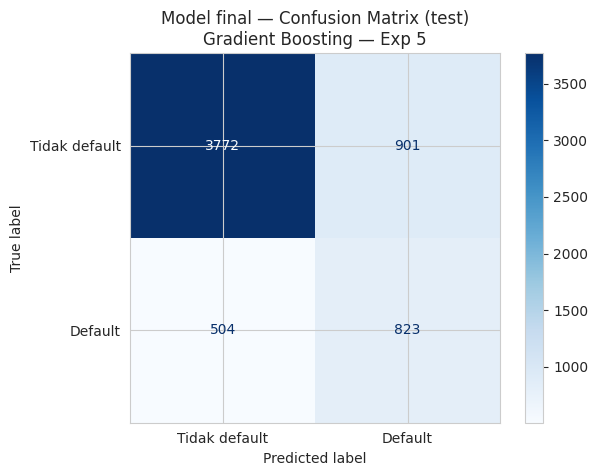

In [56]:
# Konfirmasi model final pada test set
if final_name.startswith("Gradient"):
    final_model = make_pipe(hgb).fit(X_train_clean, y_train)
else:
    final_model = tuned

pred = final_model.predict(X_test_clean)
print(classification_report(y_test, pred, target_names=["Tidak default", "Default"], digits=4))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["Tidak default", "Default"]).plot(cmap="Blues")
plt.title(f"Model final — Confusion Matrix (test)\n{final_name}"); plt.show()

## Kesimpulan
Ringkasan tabel, jawaban 5 pertanyaan, dan alasan pemilihan model final dapat dibaca langsung dari output sel-sel di atas. Poin-poin kunci yang perlu dicantumkan di PDF Final Analysis:

1. Dataset tidak memiliki missing value; masalah utama adalah kode kategori tidak valid (`EDUCATION`, `MARRIAGE`) dan kelas tidak seimbang (~22% default).
2. Karena kelas tidak seimbang, *Accuracy* tidak cukup; F1-score kelas default dipakai untuk memilih model.
3. Scaling/encoding dan penanganan imbalance (`class_weight`) diputuskan berdasarkan CV F1, bukan asumsi.
4. Seluruh preprocessing berada di dalam `Pipeline` sehingga tidak terjadi data leakage; test set hanya dipakai untuk evaluasi akhir.
5. Model final dipilih berdasarkan CV F1 dengan preferensi ke model yang lebih sederhana bila selisih performa tidak berarti.